### Datensatz aus Pickle-Datei laden

In [1]:
import pandas as pd

# Pfad zur PKL-Datei
pkl_file = '../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl'

# PKL-Datei einlesen
print(f"Lese PKL-Datei: {pkl_file}")
df_loaded = pd.read_pickle(pkl_file)
print(df_loaded.head())

Lese PKL-Datei: ../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab            Amritsar            Amritsar Branch      Savings 

In [7]:
# Bibliotheken für Visualisierungen importieren
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Bibliotheken für Hauptkompontenenanalyse importieren
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Visualisierungs-Bibliotheken geladen")

✓ Visualisierungs-Bibliotheken geladen


### Datenvorverarbeitung

1. fehlende Werte erkennen und ggfs. rausfiltern

In [8]:
# Fehlende Werte analysieren
print("=" * 80)
print("FEHLENDE WERTE")
print("=" * 80)
missing_values = df_loaded.isnull().sum()
na_values = df_loaded.isna().sum()

print("Missing null values in the dataset:")
print(missing_values)
print("=" * 80)
print("Missing N/A values in the dataset:")
print(df_loaded.isna().sum())

print("=" * 80)
print("Result:")
# Prüfen, ob überhaupt fehlende Werte vorhanden sind:
if missing_values.sum() == 0 and na_values.sum() == 0:
    print("✅ no missing values in the dataset!")
else:
    print("⚠️ missing values!!!")


FEHLENDE WERTE
Missing null values in the dataset:
Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64
Missing N/A values in the dataset:
Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Ac

2. nur alle relevanten Spalten behalten (unique ungleich 1 oder kleiner max. Wert)

In [9]:
analyzeDf = pd.DataFrame(index = list(df_loaded))
analyzeDf['type'] = df_loaded.dtypes
analyzeDf['count'] = df_loaded.count()
analyzeDf['nunique'] = df_loaded.nunique()
analyzeDf['%unique'] = analyzeDf['nunique'] /len(df_loaded) * 100
print(analyzeDf)

                            type   count  nunique   %unique
Customer_ID               object  200000   200000  100.0000
Customer_Name             object  200000   142699   71.3495
Gender                    object  200000        2    0.0010
Age                        int64  200000       53    0.0265
State                     object  200000       34    0.0170
City                      object  200000      145    0.0725
Bank_Branch               object  200000      145    0.0725
Account_Type              object  200000        3    0.0015
Transaction_ID            object  200000   200000  100.0000
Transaction_Date          object  200000       31    0.0155
Transaction_Time          object  200000    77856   38.9280
Transaction_Amount       float64  200000   197978   98.9890
Merchant_ID               object  200000   200000  100.0000
Transaction_Type          object  200000        5    0.0025
Merchant_Category         object  200000        6    0.0030
Account_Balance          float64  200000

In [10]:
# Dropping columns with one unique value
single_value_columns = [col for col in df_loaded.columns if df_loaded[col].nunique() == 1]
print("Columns with only one unique value:", single_value_columns)
df_loaded = df_loaded.drop(columns=single_value_columns)

# Dropping columns with only unique value
max_value = df_loaded['Customer_ID'].count()
max_value_columns = [col for col in df_loaded.columns if df_loaded[col].nunique() == max_value]
print("=" * 80)
print("Columns with only one unique value:", max_value_columns)
df_loaded = df_loaded.drop(columns=max_value_columns)

Columns with only one unique value: ['Transaction_Currency']
Columns with only one unique value: ['Customer_ID', 'Transaction_ID', 'Merchant_ID']


In [11]:
# Dropping columns which are not relevant for the fraud detection
columns_unrelevant = ['Customer_Email', 'Customer_Contact', 'Customer_Name']
df_loaded = df_loaded.drop(columns=columns_unrelevant)

In [12]:
# Checking columns after dropping one unique columns
df_loaded.columns

Index(['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Date', 'Transaction_Time', 'Transaction_Amount',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Description'],
      dtype='object')

In [13]:
# Checking if similar sounding columns are identical
print((df_loaded["Device_Type"] == df_loaded["Transaction_Device"]).all())

False


3. Feature Engineering

In [14]:
# Extract new features from Date and Time
df_loaded['Transaction_Date'] = pd.to_datetime(df_loaded['Transaction_Date'], format='%d-%m-%Y')
df_loaded['Transaction_Time'] = pd.to_datetime(df_loaded['Transaction_Time'], format='%H:%M:%S')

df_loaded['Transaction_Day'] = df_loaded['Transaction_Date'].dt.day
df_loaded['Transaction_Month'] = df_loaded['Transaction_Date'].dt.month
df_loaded['Transaction_Year'] = df_loaded['Transaction_Date'].dt.year 
df_loaded['Transaction_Hour'] = df_loaded['Transaction_Time'].dt.hour
df_loaded['Transaction_Minute'] = df_loaded['Transaction_Time'].dt.minute
df_loaded['Transaction_Second'] = df_loaded['Transaction_Time'].dt.second

# Dropping columns with one unique value e.g. year, month
single_value = [col for col in df_loaded.columns if df_loaded[col].nunique() == 1]
df_loaded = df_loaded.drop(columns=single_value)

# Drop 'Transaction_Date' and 'Transaction_Time' columns after feature extraction
df_loaded = df_loaded.drop(columns=['Transaction_Date', 'Transaction_Time'])

neue Feature erstellen

In [15]:
# new Feature: Ration between Account_Balance before the transaction and the transaction_amount
df_loaded['Transaction_To_Balance_Ratio'] = df_loaded['Transaction_Amount'] / (df_loaded['Account_Balance']+df_loaded['Transaction_Amount'] )

# flag for large transaction: transaction_amount is above 95% of the other transaction amouts
threshold = df_loaded['Transaction_Amount'].quantile(0.95)
df_loaded['Is_Large_Transaction']= (df_loaded['Transaction_Amount'] > threshold).astype(int)

print(df_loaded.head())

   Gender  Age        State                City                Bank_Branch  \
0    Male   60       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch   
1  Female   51  Maharashtra              Nashik              Nashik Branch   
2    Male   20        Bihar           Bhagalpur           Bhagalpur Branch   
3  Female   57   Tamil Nadu             Chennai             Chennai Branch   
4  Female   43       Punjab            Amritsar            Amritsar Branch   

  Account_Type  Transaction_Amount Transaction_Type Merchant_Category  \
0      Savings            32415.45         Transfer        Restaurant   
1     Business            43622.60     Bill Payment        Restaurant   
2      Savings            63062.56     Bill Payment         Groceries   
3     Business            14000.72            Debit     Entertainment   
4      Savings            18335.16         Transfer     Entertainment   

   Account_Balance  ...        Transaction_Location Device_Type Is_Fraud  \
0         74557.

### Hauptkomponentenanalyse durchführen + Encoding

one-hot-Encoding

In [16]:
# Encode non-numerical columns
#  Numerische und kategorische Spalten erkennen
categorical_cols = df_loaded.select_dtypes(include=["object", "category"]).columns
numeric_cols = df_loaded.select_dtypes(include=["number"]).columns

#  One-Hot-Encoding für die kategorischen Spalten
df_encoded_oneHot = pd.get_dummies(df_loaded, columns=categorical_cols, drop_first=True)

print(df_encoded_oneHot.head())


   Age  Transaction_Amount  Account_Balance  Is_Fraud  Transaction_Day  \
0   60            32415.45         74557.27         0               23   
1   51            43622.60         74622.66         0               11   
2   20            63062.56         66817.99         0               25   
3   57            14000.72         58177.08         0               19   
4   43            18335.16         16108.56         0               30   

   Transaction_Hour  Transaction_Minute  Transaction_Second  \
0                16                   4                   7   
1                17                  14                  53   
2                 3                   9                  52   
3                12                  27                   2   
4                18                  30                  46   

   Transaction_To_Balance_Ratio  Is_Large_Transaction  ...  \
0                      0.303025                     0  ...   
1                      0.368916                     

label-Encoding --> ggfs evaluieren, welches besser ist

In [17]:
# Label-Encoding für alle kategorischen Spalten
df_encoded = df_loaded.copy()
categorical_cols = df_encoded.select_dtypes(include=["object", "category"]).columns

le_dict = {}  # Speichert die Encoder pro Spalte
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print("=== Label-encodierte Tabelle ===")
print(df_encoded.head())


=== Label-encodierte Tabelle ===
   Gender  Age  State  City  Bank_Branch  Account_Type  Transaction_Amount  \
0       1   60     15   127          127             2            32415.45   
1       0   51     18   100          100             0            43622.60   
2       1   20      4    13           13             2            63062.56   
3       0   57     28    22           22             0            14000.72   
4       0   43     25     7            7             2            18335.16   

   Transaction_Type  Merchant_Category  Account_Balance  ...  \
0                 3                  5         74557.27  ...   
1                 0                  5         74622.66  ...   
2                 0                  3         66817.99  ...   
3                 2                  2         58177.08  ...   
4                 3                  2         16108.56  ...   

   Transaction_Location  Device_Type  Is_Fraud  Transaction_Description  \
0                   129            3  

PCA

In [18]:
def run_pca(df, n_components=2, df_name="DataFrame"):
    """
    Führt PCA auf einem DataFrame aus, standardisiert die Daten und gibt Ergebnisse zurück.
    """
    # Standardisieren
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    # PCA durchführen
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X_scaled)

    # DataFrame für PCA-Komponenten
    pca_df = pd.DataFrame(principal_components, columns=[f"PC{i+1}" for i in range(n_components)])

    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            index=df.columns, 
                            columns=[f"PC{i+1}" for i in range(n_components)])
    
    # Ergebnisse ausgeben
    print(f"\n=== PCA-Ergebnisse für {df_name} (erste 5 Zeilen) ===")
    print(pca_df.head())
    
    print(f"\n=== Erklärte Varianz pro Komponente ({df_name}) ===")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var:.2%}")

    print(f"\n=== Feature-Gewichte pro Hauptkomponente ({df_name}) ===")
    print(loadings.sort_values(by="PC1", ascending=False))
    
    return pca_df, loadings, pca.explained_variance_ratio_


# Beispiel: Zwei DataFrames nebeneinander vergleichen
pca_df1, loadings1, var_ratio1 = run_pca(df_encoded, df_name="df_encoded_label_encoding")
pca_df2, loadings2, var_ratio2 = run_pca(df_encoded_oneHot, df_name="df_encoded_oneHot_encoding")

# Nebeneinander darstellen (erste 5 Zeilen)
combined_pca = pd.concat([pca_df1.add_suffix('_df1'), pca_df2.add_suffix('_df2')], axis=1)
print("\n=== PCA-Komponenten nebeneinander ===")
print(combined_pca.head())


=== PCA-Ergebnisse für df_encoded_label_encoding (erste 5 Zeilen) ===
        PC1       PC2
0  2.302197 -1.269831
1  1.174214 -0.821616
2 -2.336561  0.059422
3 -2.083256 -1.654892
4 -2.670977  0.011724

=== Erklärte Varianz pro Komponente (df_encoded_label_encoding) ===
PC1: 14.30%
PC2: 9.84%

=== Feature-Gewichte pro Hauptkomponente (df_encoded_label_encoding) ===
                                   PC1       PC2
City                          0.576811 -0.009482
Bank_Branch                   0.576811 -0.009482
Transaction_Location          0.576776 -0.009488
Transaction_To_Balance_Ratio  0.010756  0.659274
Transaction_Amount            0.009823  0.564373
Account_Type                  0.006261 -0.004772
Is_Large_Transaction          0.005800  0.324289
Transaction_Minute            0.003196 -0.001799
Is_Fraud                      0.002265 -0.003799
Transaction_Day               0.001916 -0.001823
Transaction_Description       0.001283 -0.003218
Transaction_Hour              0.000556  0.0


=== PCA-Ergebnisse für df_encoded_oneHot_encoding (erste 5 Zeilen) ===
        PC1       PC2
0 -0.318074 -0.675543
1 -0.337801 -0.768565
2 -0.346599 -0.675759
3 -0.332765 -0.726692
4 -0.803688  5.575500

=== Erklärte Varianz pro Komponente (df_encoded_oneHot_encoding) ===
PC1: 0.60%
PC2: 0.60%

=== Feature-Gewichte pro Hauptkomponente (df_encoded_oneHot_encoding) ===
                                                  PC1       PC2
Transaction_Location_Kavaratti, Lakshadweep  0.490415  0.040965
Bank_Branch_Kavaratti Branch                 0.490415  0.040965
State_Lakshadweep                            0.490415  0.040965
City_Kavaratti                               0.490415  0.040965
Transaction_Description_Credit card payment  0.004613 -0.000602
...                                               ...       ...
State_Punjab                                -0.035314  0.249227
State_Chandigarh                            -0.043950  0.316036
Transaction_Location_Chandigarh, Chandigarh -0.043950

Korrelationsmatrix


=== Korrelationsmatrix der label-encodierten Features ===
                                Gender       Age     State      City  \
Gender                        1.000000  0.001692  0.002899 -0.000299   
Age                           0.001692  1.000000 -0.004638 -0.002284   
State                         0.002899 -0.004638  1.000000 -0.046278   
City                         -0.000299 -0.002284 -0.046278  1.000000   
Bank_Branch                  -0.000299 -0.002284 -0.046278  1.000000   
Account_Type                  0.001260 -0.000281 -0.002314  0.007245   
Transaction_Amount            0.001468 -0.003087  0.002480  0.005674   
Transaction_Type              0.001339 -0.001291 -0.000130  0.000101   
Merchant_Category             0.002233 -0.000381  0.001078 -0.001047   
Account_Balance              -0.000392  0.000269  0.000136 -0.002628   
Transaction_Device            0.002109  0.002429  0.001103 -0.001441   
Transaction_Location         -0.000261 -0.002291 -0.044936  0.999910   
Devic

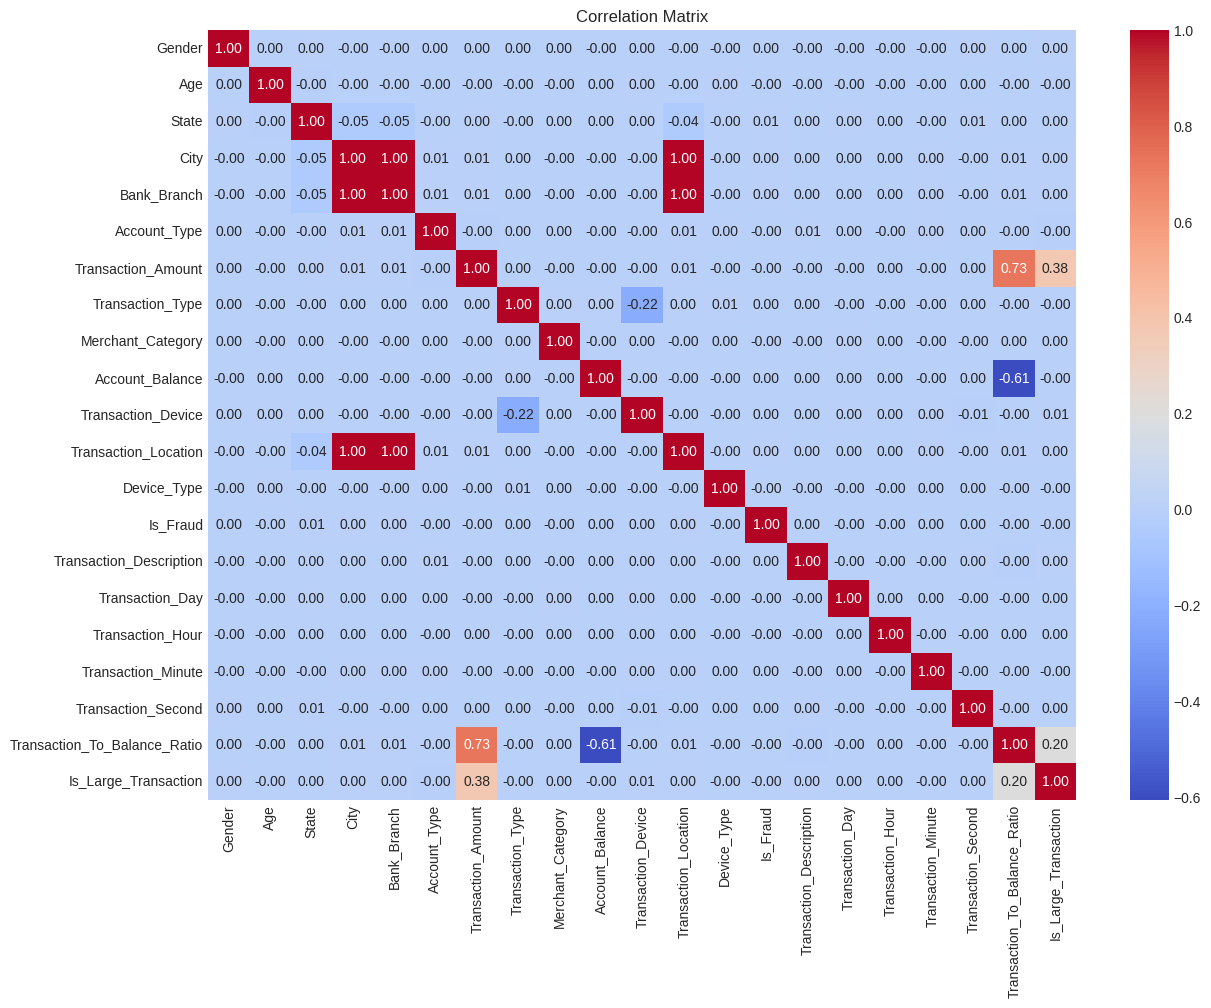

In [19]:
# Korrelationsmatrix der label-encodierten Features
corr_matrix = df_encoded.corr()
print("\n=== Korrelationsmatrix der label-encodierten Features ===")
print(corr_matrix)

# Heatmap visualisieren
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

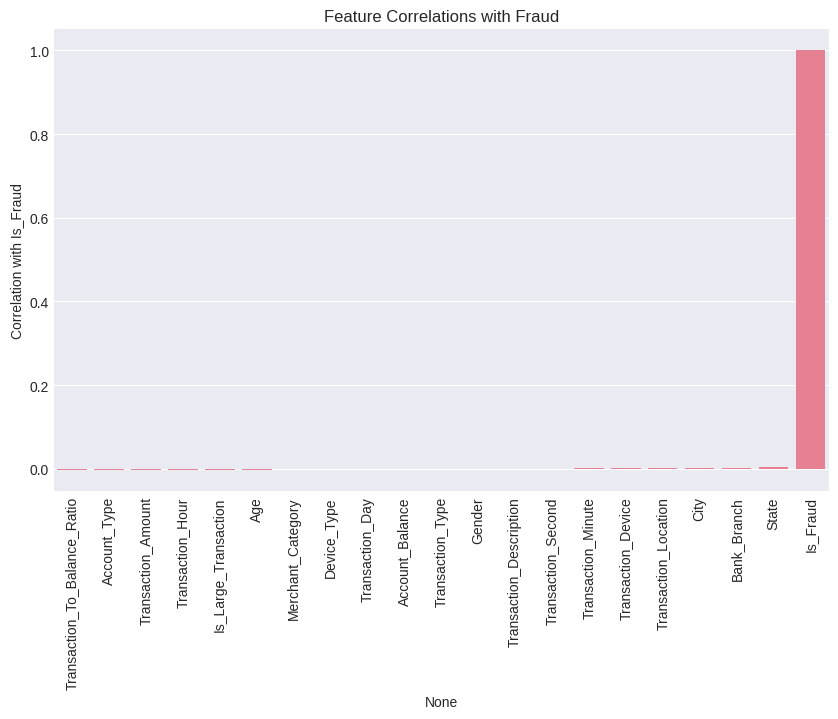

In [20]:
corr = df_encoded.corr()['Is_Fraud'].sort_values(ascending=False)
corr = corr.sort_values() 

plt.figure(figsize=(10,6))
sns.barplot(x=corr.index, y=corr.values)
plt.xticks(rotation=90)
plt.ylabel('Correlation with Is_Fraud')
plt.title('Feature Correlations with Fraud')
plt.show()

### Vorverarbeitung in neuer Datei abspeichern

In [21]:
output_file = "daten_vorverarbeitet.pkl"
df_loaded.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

output_file = "daten_vorverarbeitet_encoded.pkl"
df_encoded.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

Neue Datei gespeichert als: daten_vorverarbeitet.pkl
Neue Datei gespeichert als: daten_vorverarbeitet_encoded.pkl


In [22]:
print(df_loaded.head())
print("=" * 80)
print("Encoded:")
print(df_encoded.head())

   Gender  Age        State                City                Bank_Branch  \
0    Male   60       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch   
1  Female   51  Maharashtra              Nashik              Nashik Branch   
2    Male   20        Bihar           Bhagalpur           Bhagalpur Branch   
3  Female   57   Tamil Nadu             Chennai             Chennai Branch   
4  Female   43       Punjab            Amritsar            Amritsar Branch   

  Account_Type  Transaction_Amount Transaction_Type Merchant_Category  \
0      Savings            32415.45         Transfer        Restaurant   
1     Business            43622.60     Bill Payment        Restaurant   
2      Savings            63062.56     Bill Payment         Groceries   
3     Business            14000.72            Debit     Entertainment   
4      Savings            18335.16         Transfer     Entertainment   

   Account_Balance  ...        Transaction_Location Device_Type Is_Fraud  \
0         74557.

### Zwischenstand:

Datenvorverarbeitung:
- Spalten auf n/a und null überprüft --> keine fehlenden Werte (siehe auch Datenanalyse)
- Spalten mit nur einem uniquen Wert oder ausschließlich uniquen Werten (z.B. IDs) entfert, da sie nicht aufschlussreich für die Betrugserkennung sind
- Spalten mit nichtaussagekräftigen Werten rausgelöscht (z.B. Customer_email)
- Zeit- und Datumsmerkmale in einzelne Spalten aufgeteilt und Jahr und Monat gelöscht (da unique)
- neue Merkmale Transaction_AccountBalance_Ration und Is_large_transaction hinzugefügt

Hauptkomponentenanalyse durchgeführt: 
- kategorische Merkmale encoden - einmal mit one-hot-encoding und einmal mit label-encoding --> für eins entscheiden --> **Label-Encoding**
- ggfs Mermale mit geringen Anteilen noch rauslöschen, aber ich würde erstmal eine KI mit allen verbliebenen Merkmalen trainieren und dann testen, ob löschen sinnvoll

Daten in Trainings-, Test- und Validierungsdaten aufgeteil (siehe nachfolgenden Ordner: 3. Datenteilung)
- training = 70 %
- validierung & test = je 15 %
--> die Zeilen mit den Betrugsfällen wurden dabei anteilig gleichmäßig verteilt
- ggfs. noch synthetische Betrugsfälle generieren (je nach Bedarf)- KI trainieren und testen
- ggfs Dateipfad ändern und die vorverarbeiteten und ENCODIERTEN Daten nutzen 